In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [3]:
cash = 1_000_000

In [4]:
from priceloader import PriceLoader

# Load the data
data_dir = "../data/"
    
loader = PriceLoader("2005-01-01", "2025-01-01", data_dir)
tickers = loader.fetch_sp500_tickers()
if os.path.isdir(data_dir):
    if not os.listdir(data_dir):
        print("Batch downloading data")
        loader.batch_download(tickers=tickers)
    else:
        print("Data already downloaded")
else:
    print("Data already downloaded")

Data already downloaded


/Users/cmbenello/Coding/uchicago/grad/finm-325/src/priceloader.py:28: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)


In [5]:
_ = loader.read_ticker("aapl")
prices = loader.batch_read_close()
volumes = loader.batch_read_volume() 

# print(prices.head())

print("xtx")
print(volumes.head())

xtx
                EMN       HAL       CI     CBRE      MCO      DGX  IQV  \
Date                                                                     
2005-01-03  1915200   9752000  2595600  1862400  1329600   794200  NaN   
2005-01-04  9916200   8532800  4178100  1307400  1072600  1031800  NaN   
2005-01-05  4925200  11291200  3882300  2315100   983000  1408000  NaN   
2005-01-06  3350200  10787600  4538700  1278300  1021400  1601200  NaN   
2005-01-07  1722200   7503600  3200100   902400   669600  1974600  NaN   

                 TGT      GPN      RL  ...      AXP  GEV       CL       IP  \
Date                                   ...                                   
2005-01-03   4434100  1226400  741300  ...  5251571  NaN  5383200  2781147   
2005-01-04   2424500  1287200  767400  ...  4642294  NaN  3895800  3240192   
2005-01-05   2580900  1202000  362100  ...  4681481  NaN  8916000  6353925   
2005-01-06  13875000  1575600  174900  ...  4947675  NaN  5987200  3187081   
2005-01-0

In [ ]:
from strategies import (
    Benchmark_Strategy,
    MACDStrategy,
    MovingAverageStrategy,
    RSIStrategy,
    VolatilityBreakoutStrategy,
)

bench = Benchmark_Strategy(
    initial_cash=1_000_000.0, 
    participation_rate=0.10,
    adv_window=20,            
    dollar_cap_usd=None        
)

bench_signals = bench.generate_signals(
    close_df=prices,
    vol_df=volumes,
    dollar_volume_threshold=500_000,   # per name per day (adjust to taste)
    per_name_dollar_cap=2_000_000      # optional hard per-name cap
)

#Generate signals
mas = MovingAverageStrategy(20, 50)
mas_signals = mas.generate_signals(prices)

vbs = VolatilityBreakoutStrategy(20)
vbs_signals = vbs.generate_signals(prices)

macd = MACDStrategy(12, 26, 9) # I think default strategies
macd_signals = macd.generate_signals(prices)

rsi = RSIStrategy(14, 30) # Same for this
rsi_signals = rsi.generate_signals(prices)

TypeError: positive() got an unexpected keyword argument 'lower'

In [7]:
from backtester import Backtester, BacktestResult

bt = Backtester(prices, initial_cash=1_000_000.0)
results = {
    "Bench": bt.run(bench_signals),
    "RSI": bt.run(rsi_signals),
    "MACD": bt.run(macd_signals),
    "MA": bt.run(mas_signals),
    "VolBreak": bt.run(vbs_signals),
}


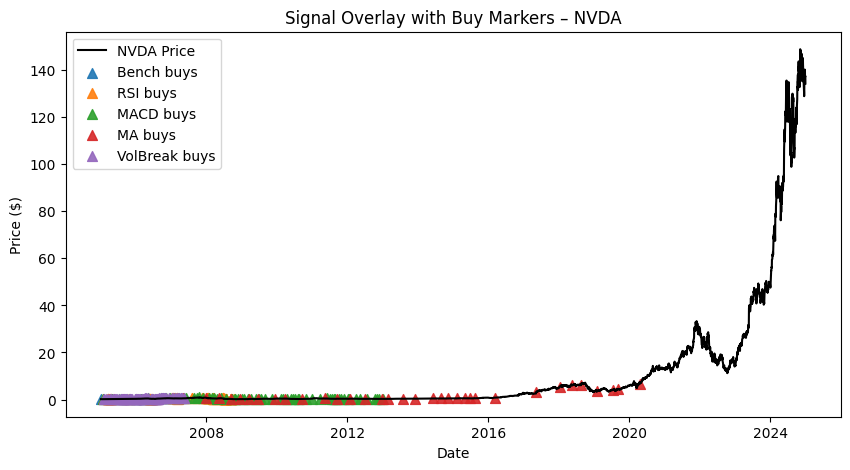

In [8]:
import matplotlib.pyplot as plt

ticker = "NVDA"
plt.figure(figsize=(10,5))

# price line
plt.plot(prices[ticker], label=f"{ticker} Price", color="black")

# overlay buy markers from each strategy's BacktestResult
for name, res in results.items():                   # results[name] -> BacktestResult
    eb = res.executed_buys                          # DataFrame (dates × tickers) with 0/1
    if ticker not in eb.columns:
        continue
    buy_dates = eb.index[eb[ticker] == 1]
    plt.scatter(
        buy_dates,
        prices.loc[buy_dates, ticker],
        label=f"{name} buys",
        marker="^",
        s=50,
        alpha=0.9,
    )

plt.title(f"Signal Overlay with Buy Markers – {ticker}")
plt.xlabel("Date"); plt.ylabel("Price ($)")
plt.legend(); plt.show()

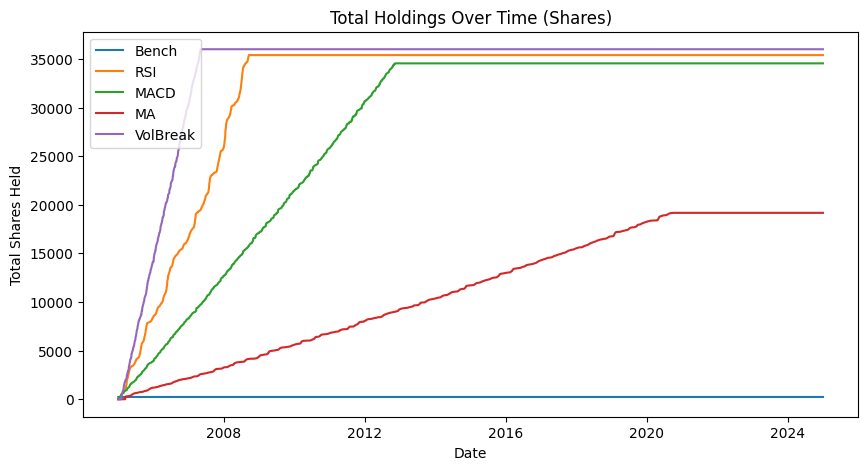

In [9]:
#Plot holdings
plt.figure(figsize=(10,5))

for name, res in results.items():
    total_holdings = res.shares.sum(axis=1)
    plt.plot(total_holdings.index, total_holdings.values, label=name)

plt.title("Total Holdings Over Time (Shares)")
plt.xlabel("Date")
plt.ylabel("Total Shares Held")
plt.legend()
plt.show()

                    Bench        RSI            MACD         MA   VolBreak
Date                                                                      
2005-01-03  992356.268923  1000000.0  1000000.000000  1000000.0  1000000.0
2005-01-04  992356.268923  1000000.0  1000000.000000  1000000.0  1000000.0
2005-01-05  992356.268923  1000000.0   998554.173222  1000000.0  1000000.0
2005-01-06  992356.268923  1000000.0   998166.447344  1000000.0  1000000.0
2005-01-07  992356.268923  1000000.0   997438.331249  1000000.0  1000000.0


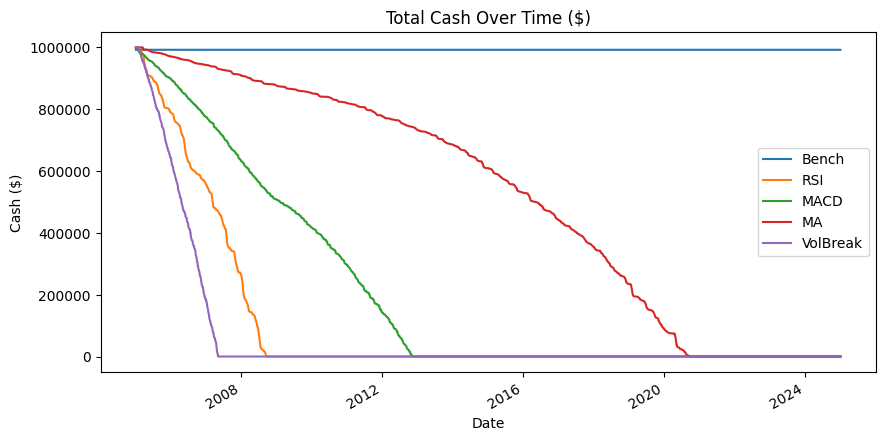

In [10]:
#Plot cash
cash_df = pd.DataFrame({name: res.cash.astype("float64") for name, res in results.items()})

print(cash_df.head())
ax = cash_df.plot(figsize=(10,5), title="Total Cash Over Time ($)")
ax.set_xlabel("Date")
ax.set_ylabel("Cash ($)")
ax.ticklabel_format(style="plain", axis="y")
plt.show()

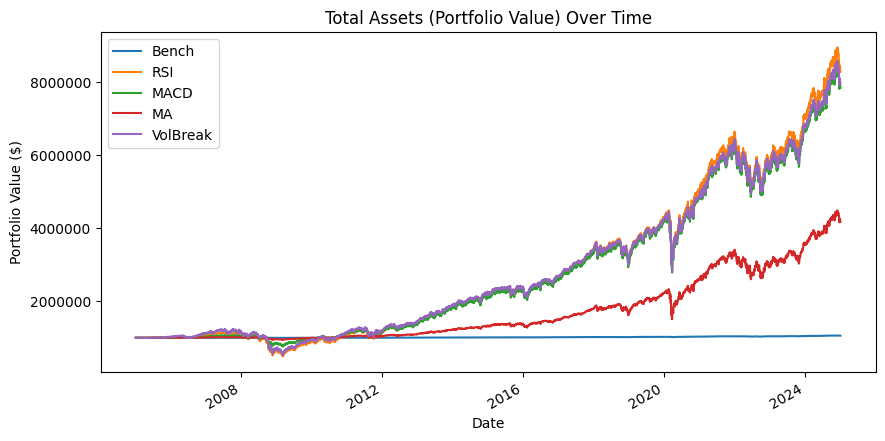

In [11]:

assets_df = pd.concat(
    {name: r.portfolio_value.astype("float64") for name, r in results.items()},
    axis=1
).sort_index().dropna(how="all")

ax = assets_df.plot(figsize=(10,5), title="Total Assets (Portfolio Value) Over Time")
ax.set_xlabel("Date"); ax.set_ylabel("Portfolio Value ($)")
ax.ticklabel_format(style="plain", axis="y")
plt.show()

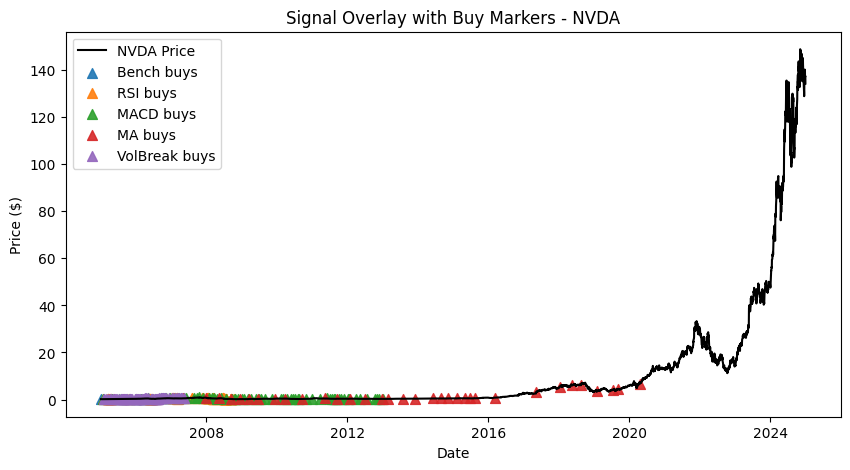

In [12]:
import matplotlib.pyplot as plt

ticker = "NVDA"
plt.figure(figsize=(10,5))

# price line
plt.plot(prices[ticker], label=f"{ticker} Price", color="black")

# overlay buy markers from each strategy's BacktestResult
for name, res in results.items():                   # results[name] -> BacktestResult
    eb = res.executed_buys                          # DataFrame (dates × tickers) with 0/1
    if ticker not in eb.columns:
        continue
    buy_dates = eb.index[eb[ticker] == 1]
    plt.scatter(
        buy_dates,
        prices.loc[buy_dates, ticker],
        label=f"{name} buys",
        marker="^",
        s=50,
        alpha=0.9,
    )

plt.title(f"Signal Overlay with Buy Markers - {ticker}")
plt.xlabel("Date"); plt.ylabel("Price ($)")
plt.legend(); plt.show()

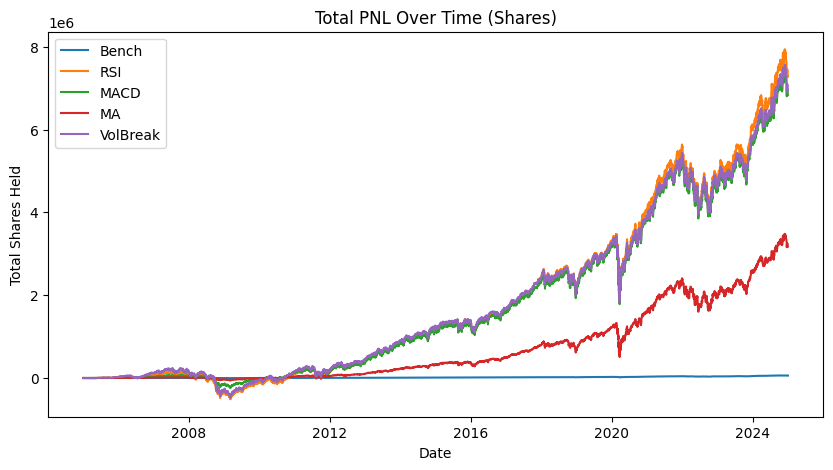

In [13]:
#Plot pnl
plt.figure(figsize=(10,5))

for name, res in results.items():
    pnl = res.pnl
    plt.plot(pnl.index, pnl.values, label=name)

plt.title("Total PNL Over Time (Shares)")
plt.xlabel("Date")
plt.ylabel("Total Shares Held")
plt.legend()
plt.show()

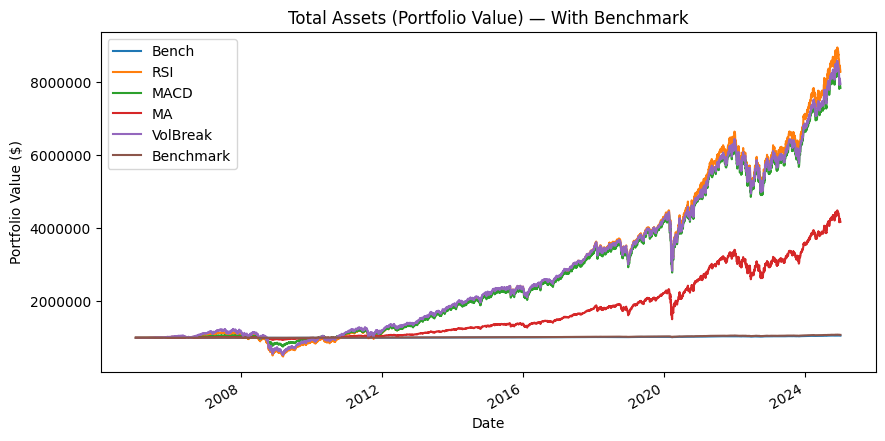

In [14]:
# one buy signal per ticker on the first date only
bench_signals = pd.DataFrame(0, index=prices.index, columns=prices.columns, dtype="int8")
bench_signals.iloc[0, :] = 1

bench_res = bt.run(bench_signals)

results_with_bench = {**results, "Benchmark": bench_res}

# plot
assets_df = pd.concat({name: r.portfolio_value for name, r in results_with_bench.items()}, axis=1)
ax = assets_df.plot(figsize=(10,5), title="Total Assets (Portfolio Value) — With Benchmark")
ax.set_xlabel("Date"); ax.set_ylabel("Portfolio Value ($)")
ax.ticklabel_format(style="plain", axis="y")
plt.show()